This file contains the calculation of the return period and return level of extreme val

In [ ]:
#Connect google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

In [ ]:
#Franklin county
file = pd.read_csv("/content/drive/MyDrive/Thesis/Datasets/extreme/franklin-1960-2023.csv")
file.head()

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,TMAX,TMAX_ATTRIBUTES,TMIN,TMIN_ATTRIBUTES
0,US1NYFK0007,"SARANAC LAKE 6.2 N, NY US",44.413592,-74.152111,521.2,2014-11-18,NaN,NaN,NaN,NaN
1,US1NYFK0007,"SARANAC LAKE 6.2 N, NY US",44.413592,-74.152111,521.2,2014-11-19,NaN,NaN,NaN,NaN
2,US1NYFK0007,"SARANAC LAKE 6.2 N, NY US",44.413592,-74.152111,521.2,2014-11-20,NaN,NaN,NaN,NaN
3,US1NYFK0007,"SARANAC LAKE 6.2 N, NY US",44.413592,-74.152111,521.2,2014-11-21,NaN,NaN,NaN,NaN
4,US1NYFK0007,"SARANAC LAKE 6.2 N, NY US",44.413592,-74.152111,521.2,2014-11-22,NaN,NaN,NaN,NaN


In [ ]:
#Nan
nan_count_tmax = file['TMAX'].isnull().sum()
nan_count_tmin = file['TMIN'].isnull().sum()

print(nan_count_tmax)
print(nan_count_tmin)

7404
7393


In [ ]:
#Delete NaN values in 'TMAX' and 'TMIN' columns
new_file = file.dropna(subset=['TMAX', 'TMIN'])

#new_file.head()

In [ ]:
#Change format to datetime
new_file['DATE'] = pd.to_datetime(new_file['DATE'])

date_range = pd.date_range(start='1960-01-01', end='2023-12-31')

#Check missing dates
missing_dates = date_range[~date_range.isin(new_file['DATE'])]
missing_dates

<ipython-input-54-00f1a8985fe4>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_file['DATE'] = pd.to_datetime(new_file['DATE'])


DatetimeIndex(['1985-11-01', '1985-11-02', '1985-11-03', '1985-11-04',
               '1985-11-05', '1985-11-06', '1985-11-07', '1985-11-08',
               '1985-11-09', '1985-11-10', '1985-11-11', '1985-11-12',
               '1985-11-13', '1985-11-14', '1985-11-15', '1985-11-16',
               '1985-11-17', '1985-11-18', '1985-11-19', '1985-11-20',
               '1985-11-21', '1985-11-22', '1985-11-23', '1985-11-24',
               '1985-11-25', '1985-11-26', '1985-11-27', '1985-11-28',
               '1985-11-29', '1985-11-30'],
              dtype='datetime64[ns]', freq='D')

In [ ]:
#Count each date
date_counts = new_file['DATE'].value_counts()

#More than two (duplicates)
dates_with_multiple_values = date_counts[date_counts > 1]

#print("Dates with more than two values:")
df = dates_with_multiple_values.to_frame()
#print(df.sort_values)
df

,count
DATE,
1965-12-13,5
1966-03-04,5
1966-03-02,5
1966-03-01,5
1966-02-28,5
...,...
2011-08-04,2
2011-07-30,2
2011-07-31,2


In [ ]:
#ex) '1960-01-01'
specific_date_rows = new_file[new_file['DATE'] == '1960-01-01']
#specific_date_rows = df[df['DATE'] == '1960-01-01']

#print("Rows with DATE == '1960-01-01':")
specific_date_rows

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,TMAX,TMAX_ATTRIBUTES,TMIN,TMIN_ATTRIBUTES
3157,USC00306459,"PAUL SMITHS, NY US",44.43333,-74.26667,509.0,1960-01-01,-6.1,",,0",-24.4,",,0"
22136,USC00307472,"SARANAC LAKE, NY US",44.33333,-74.13333,481.9,1960-01-01,-4.4,",,0",-22.2,",,0"
41083,USC00301387,"CHASM FALLS, NY US",44.75000,-74.21667,323.1,1960-01-01,-2.2,",,0",-18.3,",,0"
58118,USC00308631,"TUPPER LAKE SUNMOUNT, NY US",44.23070,-74.43820,512.1,1960-01-01,-4.4,",,0",-22.8,",,0"


In [ ]:
#calculate average for 'TMAX' and 'TMIN' - for each date group
date_groups = new_file.groupby('DATE')[['TMAX', 'TMIN']].mean().reset_index()

print("Averaged DataFrame:")
print(date_groups.head())

Averaged DataFrame:
        DATE   TMAX    TMIN
0 1960-01-01 -4.275 -21.925
1 1960-01-02  0.150 -20.725
2 1960-01-03  3.325  -4.425
3 1960-01-04 -0.400  -6.825
4 1960-01-05 -4.850 -14.450


In [ ]:
date_groups

,DATE,TMAX,TMIN
0,1960-01-01,-4.275000,-21.925000
1,1960-01-02,0.150000,-20.725000
2,1960-01-03,3.325000,-4.425000
3,1960-01-04,-0.400000,-6.825000
4,1960-01-05,-4.850000,-14.450000
...,...,...,...
23341,2023-12-27,9.633333,1.466667
23342,2023-12-28,6.300000,2.966667
23343,2023-12-29,5.366667,1.300000
23344,2023-12-30,2.800000,-3.300000


In [ ]:
#Count occurances
date_counts = date_groups['DATE'].value_counts()

#more than two?
dates_with_multiple_values2 = date_counts[date_counts > 1]

#print("Dates with more than two values:")
#df = dates_with_multiple_values.to_frame()
#print(df.sort_values)
print(dates_with_multiple_values2)

Series([], Name: count, dtype: int64)


In [ ]:
date_groups_month

,DATE,TMAX,TMIN
0,1960-01-01,-4.275,-21.925
1,1960-01-02,0.150,-20.725
2,1960-01-03,3.325,-4.425
3,1960-01-04,-0.400,-6.825
4,1960-01-05,-4.850,-14.450
...,...,...,...
23007,2023-01-27,-3.550,-14.950
23008,2023-01-28,-0.300,-10.750
23009,2023-01-29,1.100,-8.800
23010,2023-01-30,-4.950,-9.650


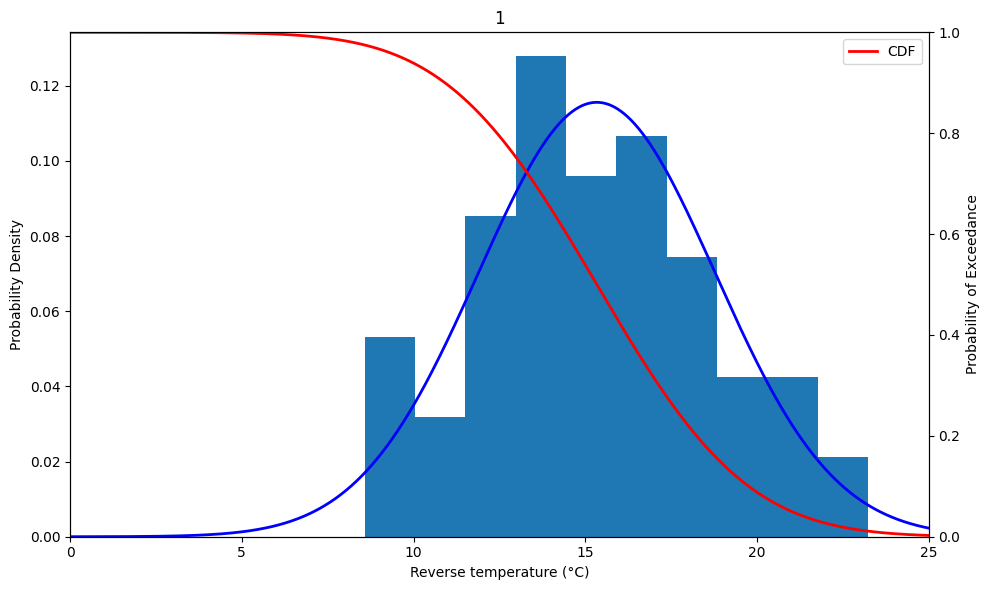

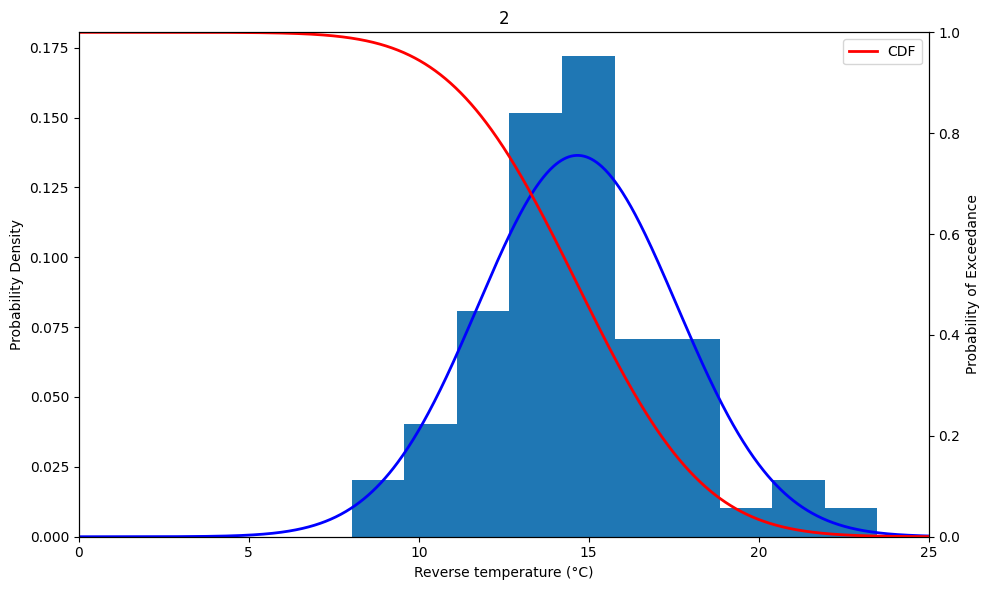

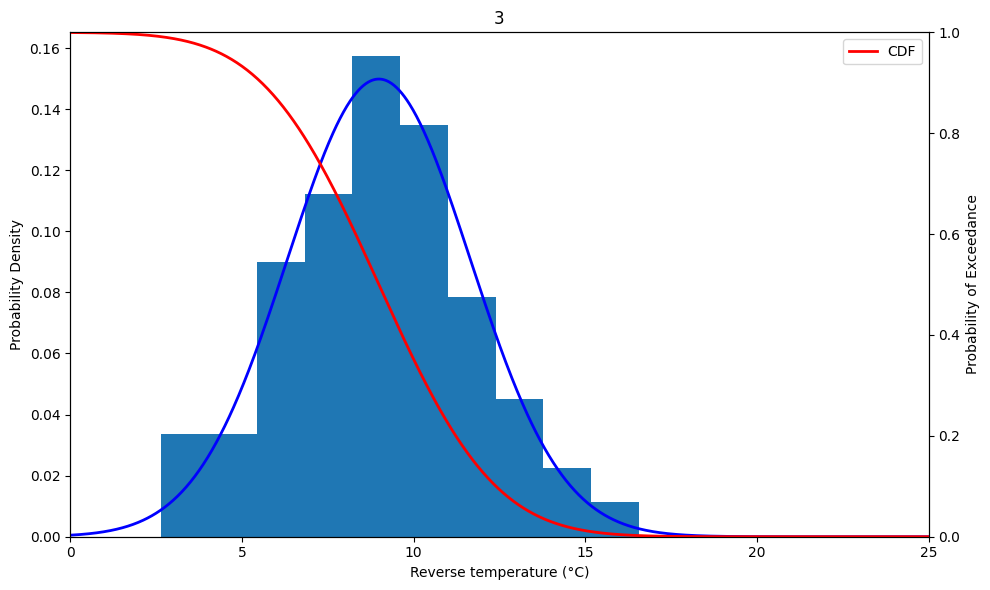

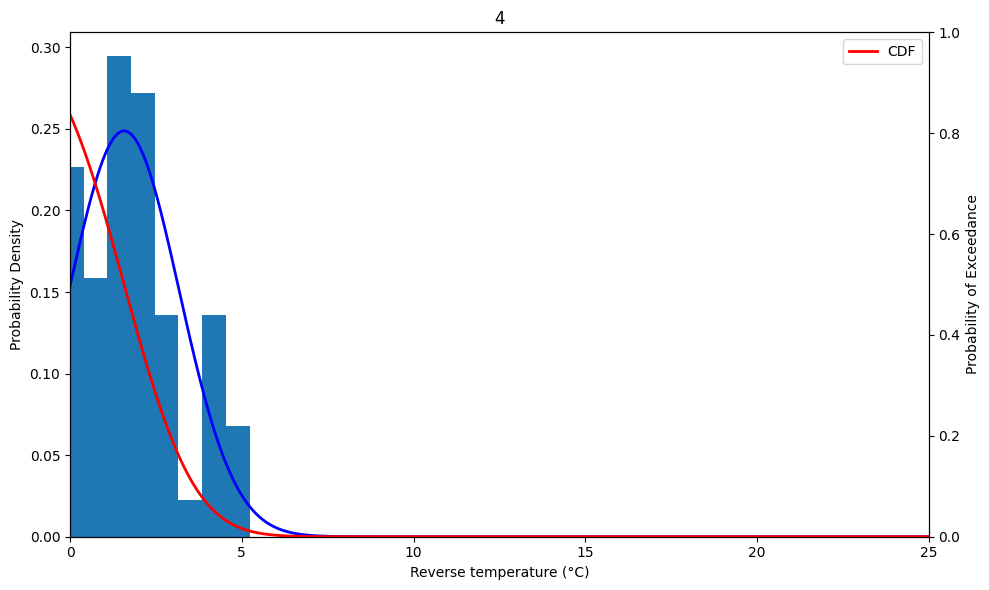

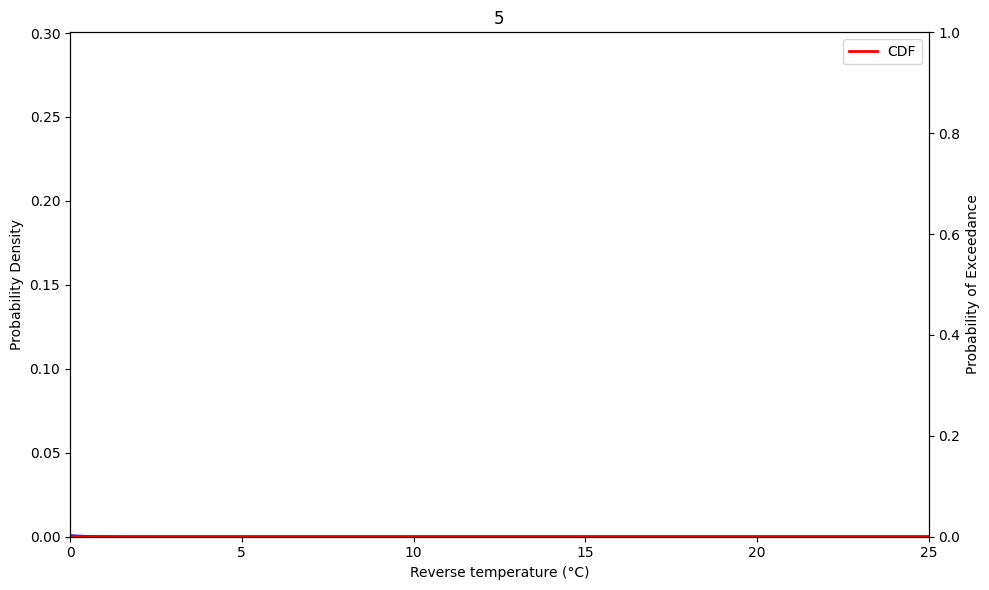

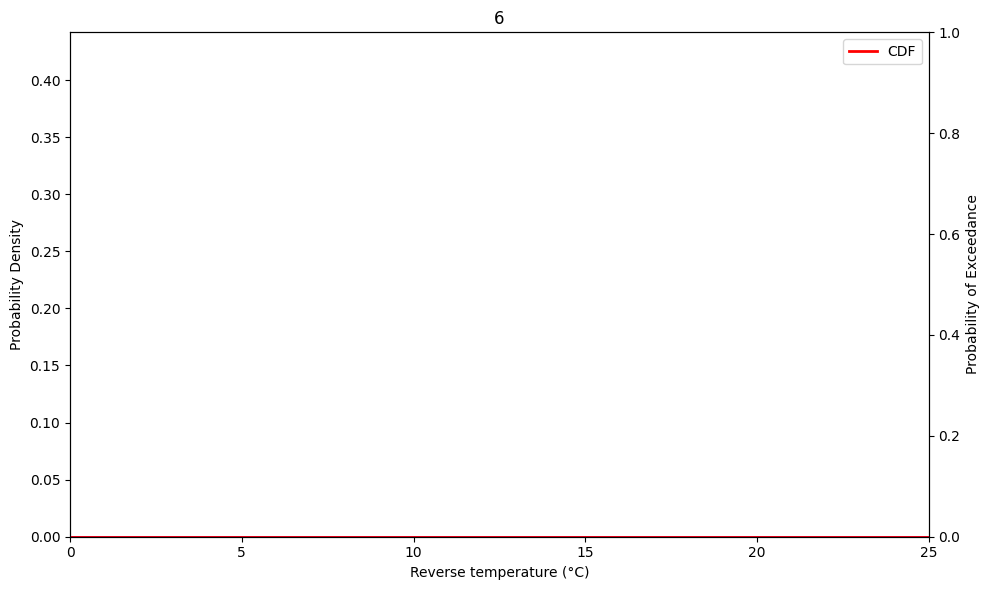

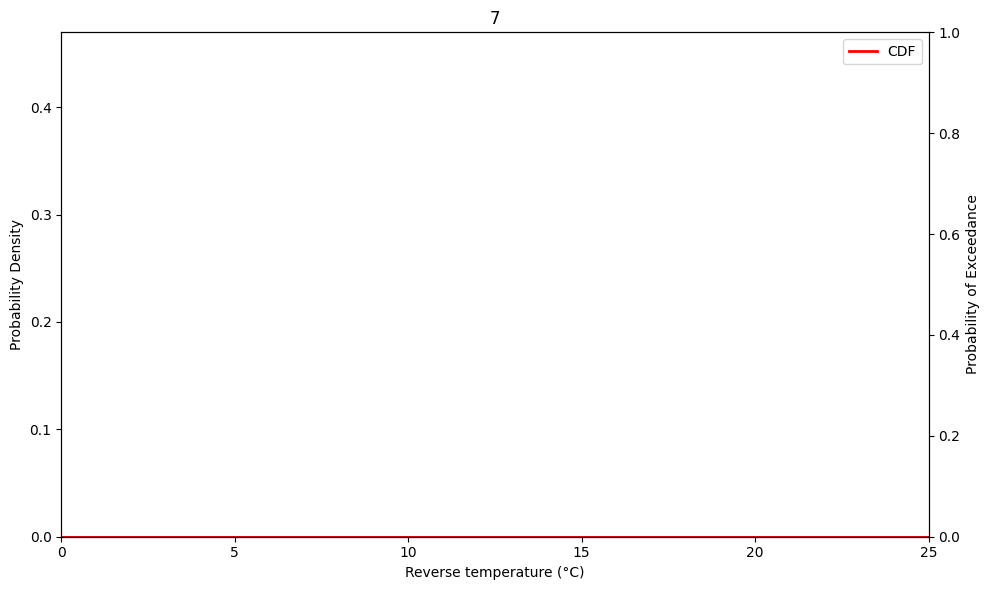

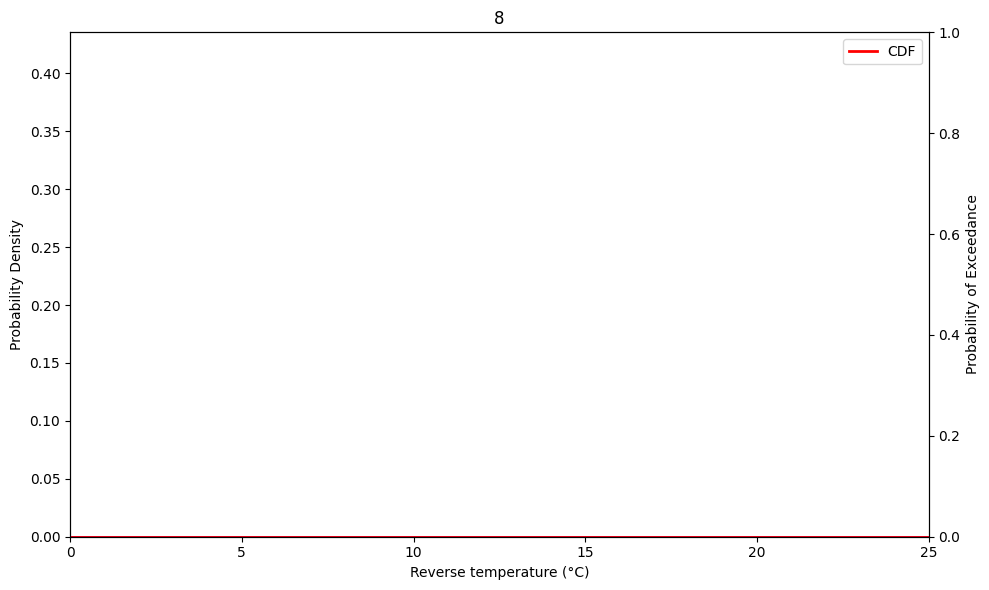

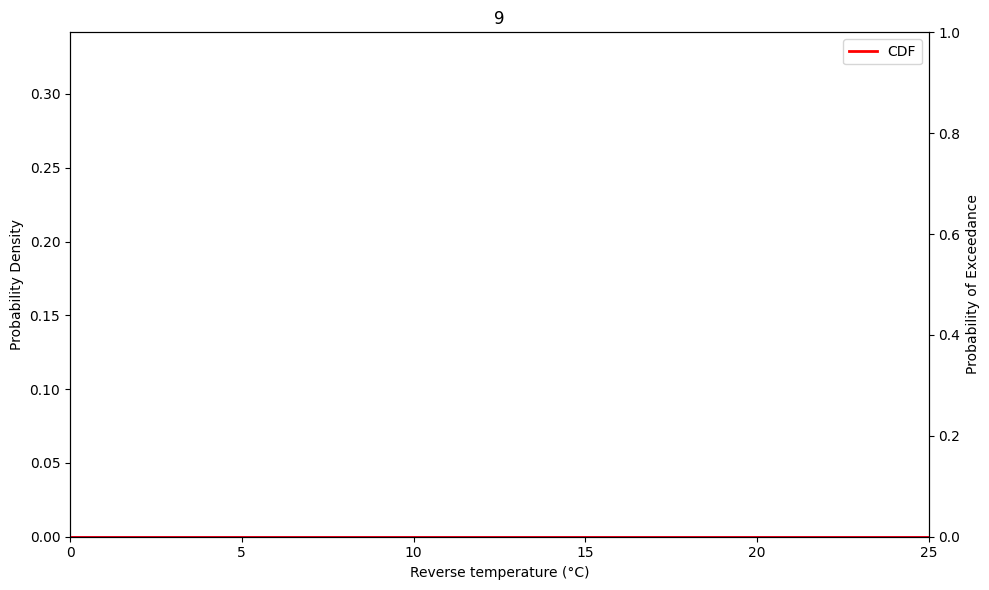

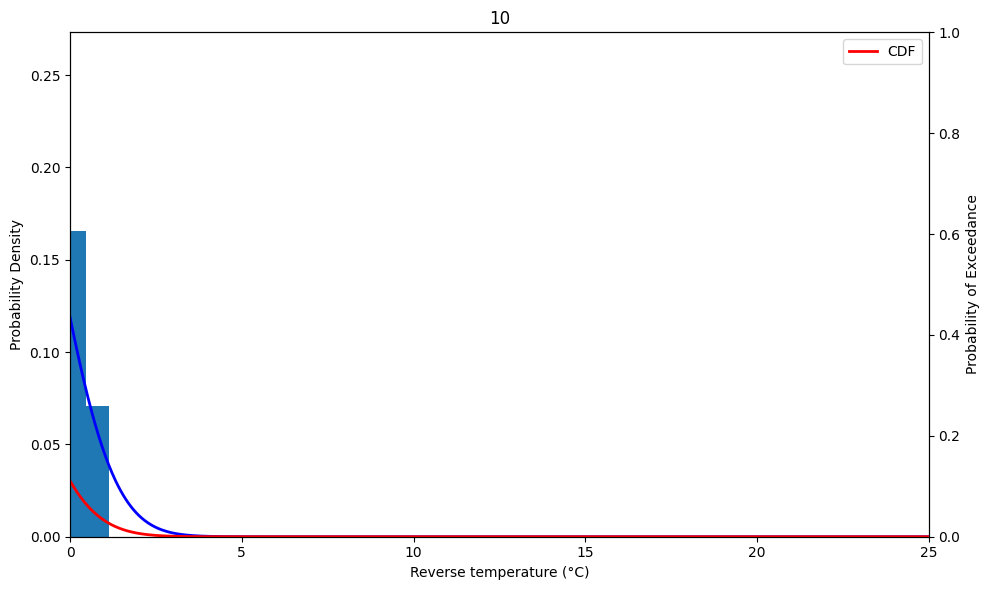

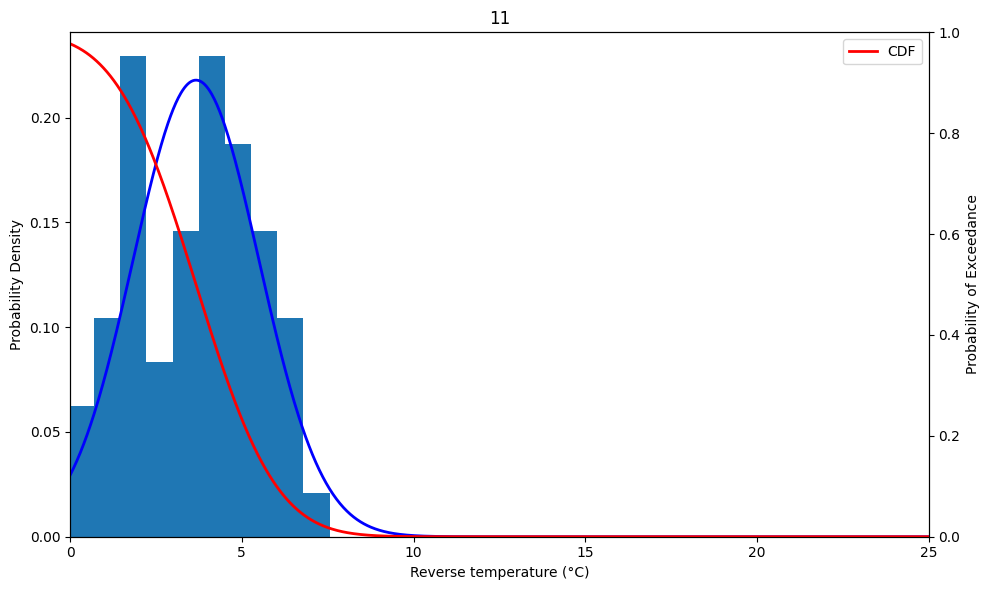

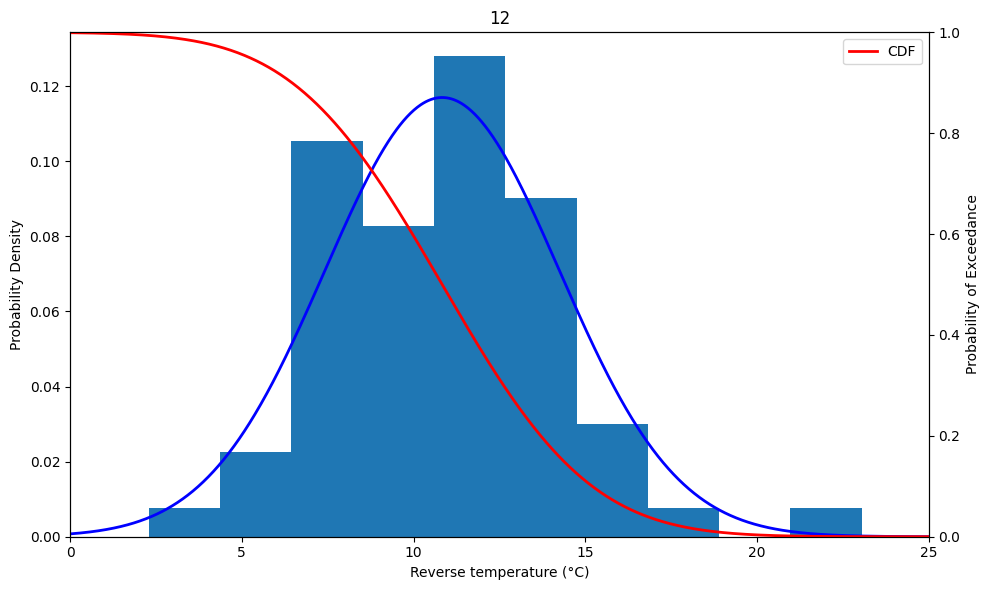

In [ ]:
date_groups['DATE'] = pd.to_datetime(date_groups['DATE'], format="%Y-%m-%d")

for i in range(12):
  #Filter data for February
  date_groups_month = date_groups[date_groups['DATE'].dt.month == i+1]

  #Calculate mean and min of TMIN grouped by year
  mean_min_t = date_groups_month.groupby(date_groups_month['DATE'].dt.year)['TMIN'].mean().reset_index()
  min_min_t = date_groups_month.groupby(date_groups_month['DATE'].dt.year)['TMIN'].min().reset_index()

  t_mean_min = mean_min_t['TMIN']
  #t_mean_min


  #print(mean_min_t)
  #print(min_min_t)

  #Reverse the sign of the temperature data
  reverse = -t_mean_min
  #Calculate mean and standard deviation
  t_mean = np.mean(reverse)
  t_std = np.std(reverse)

  #Plot data distribution
  plt.figure(figsize=(10, 6))

  #Plot histogram
  plt.hist(reverse, density=True)
  plt.xlim(0, 25)
  plt.xlabel('Reverse temperature (°C)')
  plt.ylabel('Probability Density')

  #PDF
  X = np.linspace(0, 25, 1000)
  y1 = norm.pdf(X, loc=t_mean, scale=t_std)
  plt.plot(X, y1, 'b-', linewidth=2, label='PDF')

  #CDF
  plt.twinx()
  plt.ylim(0, 1)
  plt.ylabel('Probability of Exceedance')
  plt.plot(X, 1 - norm.cdf(X, loc=t_mean, scale=t_std), 'r-', linewidth=2, label='CDF')
  plt.title(i+1)

  # Add legends
  plt.legend(loc='upper right')
  plt.tight_layout()

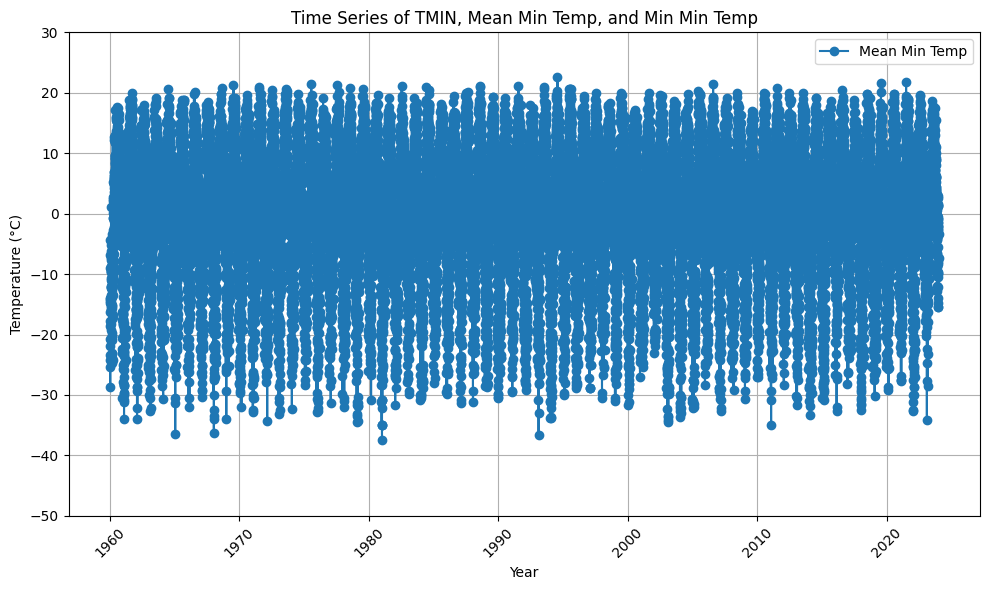

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(date_groups['DATE'], date_groups['TMIN'], label='Mean Min Temp', marker='o')
#plt.plot(mean_min_t['DATE'], mean_min_t['TMIN'], label='Mean Min Temp', marker='o')
#plt.plot(min_min_t['DATE'], min_min_t['TMIN'], label='Min Min Temp', marker='s')
plt.ylim(-50,30)
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.title('Time Series of TMIN, Mean Min Temp, and Min Min Temp')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

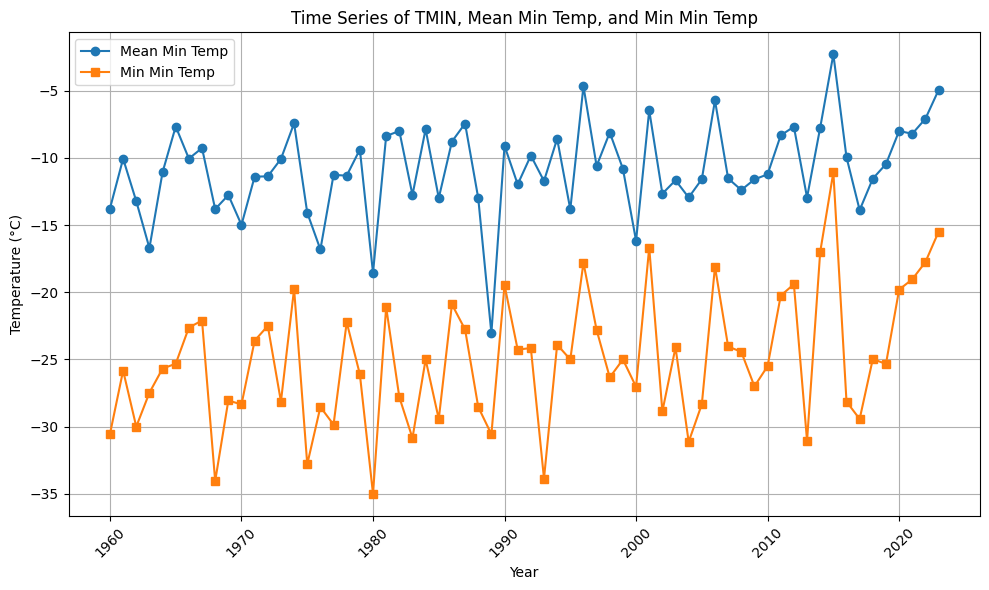

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(mean_min_t['DATE'], mean_min_t['TMIN'], label='Mean Min Temp', marker='o')
plt.plot(min_min_t['DATE'], min_min_t['TMIN'], label='Min Min Temp', marker='s')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.title('Time Series of TMIN, Mean Min Temp, and Min Min Temp')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
t_mean_min = mean_min_t['TMIN']
t_mean_min

0    -13.766935
1    -10.058871
2    -13.219355
3    -16.708065
4    -11.061290
        ...    
59   -10.460215
60    -7.995699
61    -8.202688
62    -7.083871
63    -4.949462
Name: TMIN, Length: 64, dtype: float64

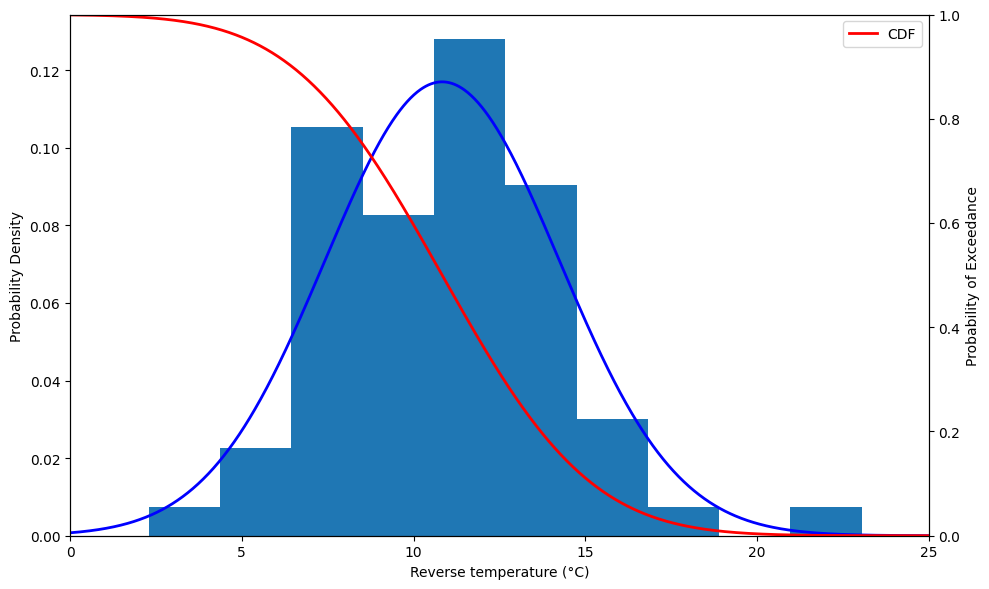

In [ ]:
reverse = -t_mean_min
# Calculate mean and standard deviation
t_mean = np.mean(reverse)
t_std = np.std(reverse)

# Plot data distribution
plt.figure(figsize=(10, 6))

# Plot histogram
plt.hist(reverse, density=True)
plt.xlim(0, 25)
plt.xlabel('Reverse temperature (°C)')
plt.ylabel('Probability Density')

# Overlay the normal distribution PDF
X = np.linspace(0, 25, 1000)
y1 = norm.pdf(X, loc=t_mean, scale=t_std)
plt.plot(X, y1, 'b-', linewidth=2, label='PDF')

# Create a new plot/axis for the CDF
plt.twinx()
plt.ylim(0, 1)
plt.ylabel('Probability of Exceedance')
plt.plot(X, 1 - norm.cdf(X, loc=t_mean, scale=t_std), 'r-', linewidth=2, label='CDF')

# Add legends
plt.legend(loc='upper right')
plt.tight_layout()

<ipython-input-79-43dcd152ec8c>:9: RuntimeWarning: divide by zero encountered in divide
  plt.scatter(1 / (1 - cdf), X_sort, c='blue', marker='o', label='Data')


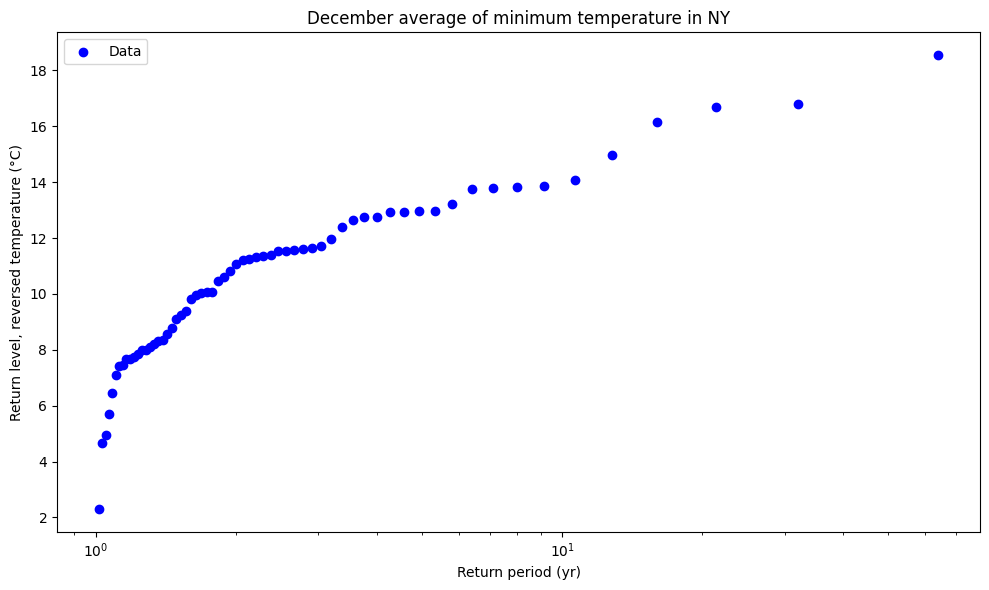

In [ ]:
plt.figure(figsize=(10, 6))

#sort data
X_sort = np.sort(reverse)
n = len(X_sort)
cdf = np.arange(1, n+1) / n

#return period
plt.scatter(1 / (1 - cdf), X_sort, c='blue', marker='o', label='Data')
plt.xscale('log')
plt.xlabel('Return period (yr)')
plt.ylabel('Return level, reversed temperature (°C)')
plt.title('December average of minimum temperature in NY')

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()